In [ ]:
!pip install opencv-python numpy pandas matplotlib scikit-learn tensorflow keras seaborn optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.9/263.9 kB 41.1 MB/s eta 0:00:00


In [ ]:
import os
import cv2
import math
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries are imported successfully!")

All libraries are imported successfully!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Update dataset_path to point to MyDrive, as class folders are directly there
dataset_path = '/content/drive/MyDrive'

if os.path.exists(dataset_path):
    # Filter to only include the specific class folders you identified
    all_items = os.listdir(dataset_path)
    classes = sorted([
        item for item in all_items
        if item.startswith('ECG Images of') or item.startswith('Normal Person')
    ])

    if classes:
        print("Classes found:", classes)
    else:
        print("No relevant class folders found in", dataset_path)
else:
    print("Dataset path not found:", dataset_path)

Mounted at /content/drive
Classes found: ['ECG Images of Myocardial Infarction Patients (240x12=2880)', 'ECG Images of Patient that have History of MI (172x12=2064)', 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)', 'Normal Person ECG Images (284x12=3408)']


In [ ]:
import os

drive_path = '/content/drive/MyDrive'
print(f"Listing contents of: {drive_path}")
if os.path.exists(drive_path):
    for item in os.listdir(drive_path):
        print(item)
else:
    print(f"Error: {drive_path} does not exist. Please ensure Google Drive is mounted correctly.")

Listing contents of: /content/drive/MyDrive
Colab Notebooks
ECG Images of Myocardial Infarction Patients (240x12=2880)
ECG Images of Patient that have abnormal heartbeat (233x12=2796)
ECG Images of Patient that have History of MI (172x12=2064)
Normal Person ECG Images (284x12=3408)


In [ ]:
X = []
y = []

for label, cls in enumerate(classes):
    class_path = os.path.join(dataset_path, cls)
    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # ECG grayscale hai
        if img is None:
            print("Cannot read:", img_path)
            continue

        img = cv2.resize(img, (128,128))  # manageable size
        img = img / 255.0  # normalize
        X.append(img)
        y.append(label)

X = np.array(X).reshape(-1,128,128,1)
y = np.array(y)

print("Total images loaded:", X.shape)

Cannot read: /content/drive/MyDrive/Normal Person ECG Images (284x12=3408)/Normal(149).jpg
Cannot read: /content/drive/MyDrive/Normal Person ECG Images (284x12=3408)/Normal(68).jpg
Cannot read: /content/drive/MyDrive/Normal Person ECG Images (284x12=3408)/Normal(141).jpg
Cannot read: /content/drive/MyDrive/Normal Person ECG Images (284x12=3408)/Normal(60).jpg
Cannot read: /content/drive/MyDrive/Normal Person ECG Images (284x12=3408)/Normal(42).jpg
Cannot read: /content/drive/MyDrive/Normal Person ECG Images (284x12=3408)/Normal(194).jpg
Cannot read: /content/drive/MyDrive/Normal Person ECG Images (284x12=3408)/Normal(213).jpg
Cannot read: /content/drive/MyDrive/Normal Person ECG Images (284x12=3408)/Normal(33).jpg
Cannot read: /content/drive/MyDrive/Normal Person ECG Images (284x12=3408)/Normal(185).jpg
Cannot read: /content/drive/MyDrive/Normal Person ECG Images (284x12=3408)/Normal(240).jpg
Total images loaded: (918, 128, 128, 1)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (734, 128, 128, 1) Test: (184, 128, 128, 1)


In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(len(classes), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,517,380 (24.86 MB)

 Trainable params: 6,516,932 (24.86 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=16, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 167ms/step - accuracy: 0.3328 - loss: 16.2295 - val_accuracy: 0.2925 - val_loss: 26.7511
Epoch 2/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3694 - loss: 1.3337 - val_accuracy: 0.2925 - val_loss: 42.6666
Epoch 3/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3869 - loss: 1.2854 - val_accuracy: 0.2925 - val_loss: 44.7446
Epoch 4/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4036 - loss: 1.3108 - val_accuracy: 0.2925 - val_loss: 43.3118
Epoch 5/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4336 - loss: 1.2629 - val_accuracy: 0.2925 - val_loss: 41.4744
Epoch 6/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3579 - loss: 1.3212 - val_accuracy: 0.2925 - val_loss: 39.1911
Epoch 7/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4217 - loss: 1.2915 - val_accuracy: 0.2925 - val_loss: 37.1618
Epoch 8/30
37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3757 - loss: 1.2897 - val_accuracy: 

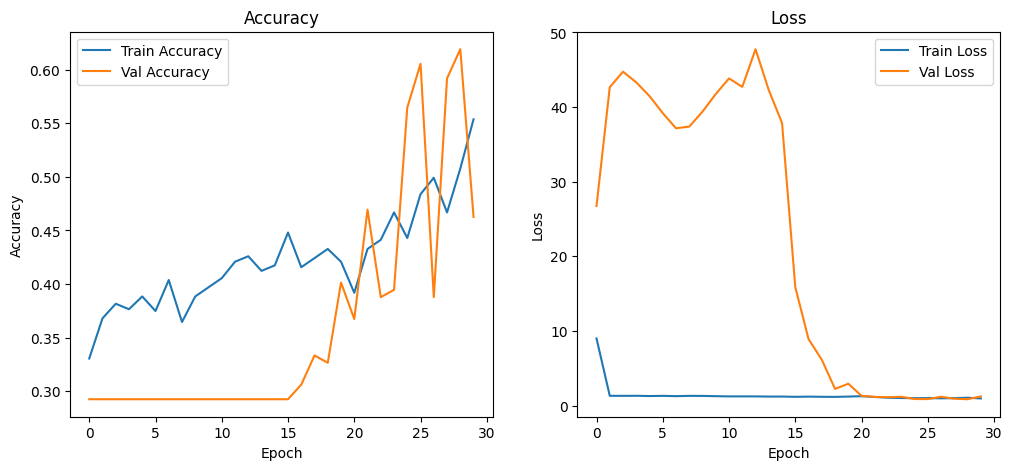

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - accuracy: 0.7254 - loss: 0.6706
Test Accuracy: 71.74%
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step


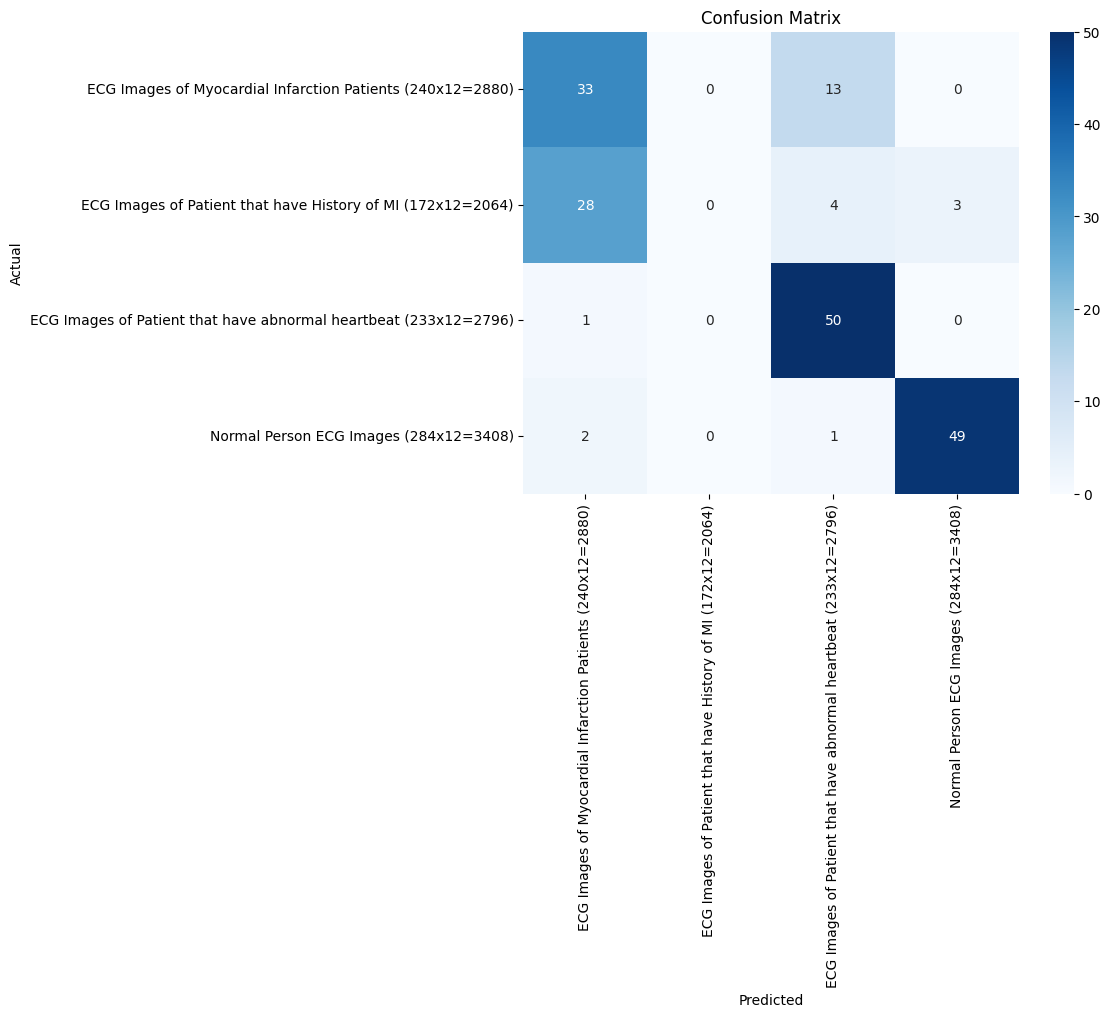

                                                                  precision    recall  f1-score   support

      ECG Images of Myocardial Infarction Patients (240x12=2880)       0.52      0.72      0.60        46
     ECG Images of Patient that have History of MI (172x12=2064)       0.00      0.00      0.00        35
ECG Images of Patient that have abnormal heartbeat (233x12=2796)       0.74      0.98      0.84        51
                          Normal Person ECG Images (284x12=3408)       0.94      0.94      0.94        52

                                                        accuracy                           0.72       184
                                                       macro avg       0.55      0.66      0.60       184
                                                    weighted avg       0.60      0.72      0.65       184



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc*100:.2f}%")

y_pred = np.argmax(model.predict(X_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred, target_names=classes))


In [ ]:
import os
import cv2
import numpy as np

def predict_new_image(img_path):
    print(f"Attempting to predict for image: {img_path}")
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print(f"Error: Could not read image at {img_path}. Please check the path and file integrity.")
        return

    print("Image read successfully. Resizing and normalizing...")
    img = cv2.resize(img, (128,128))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    img = np.expand_dims(img, axis=-1)

    print("Performing model prediction...")
    pred_prob = model.predict(img)
    pred_class_idx = np.argmax(pred_prob)
    pred_class = classes[pred_class_idx]
    print(f"Predicted Class: {pred_class} (Index: {pred_class_idx}, Probability: {pred_prob[0][pred_class_idx]:.4f})")

# Example: To use this function, replace '/content/drive/MyDrive/ECG_Data/Normal/0001.png' with the actual path to your image.
# For example, to pick an image from the 'Normal Person ECG Images' class, you could use:
predict_new_image('/content/drive/MyDrive/Normal Person ECG Images (284x12=3408)/Normal(1).jpg')

# You can also try images from other classes like:
predict_new_image('/content/drive/MyDrive/ECG Images of Myocardial Infarction Patients (240x12=2880)/MI(1).jpg')

Attempting to predict for image: /content/drive/MyDrive/Normal Person ECG Images (284x12=3408)/Normal(1).jpg
Image read successfully. Resizing and normalizing...
Performing model prediction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted Class: Normal Person ECG Images (284x12=3408) (Index: 3, Probability: 0.7286)
Attempting to predict for image: /content/drive/MyDrive/ECG Images of Myocardial Infarction Patients (240x12=2880)/MI(1).jpg
Image read successfully. Resizing and normalizing...
Performing model prediction...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Predicted Class: ECG Images of Myocardial Infarction Patients (240x12=2880) (Index: 0, Probability: 0.4242)


**CNN + HHO**

In [ ]:
import cv2, os
import numpy as np
import tensorflow as tf
from google.colab import drive
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

print("Ready.")

Ready.


In [ ]:
import cv2, os
import numpy as np
from google.colab import drive
from sklearn.model_selection import train_test_split

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Set Path (Ensure this matches your folder name exactly)
dataset_path = '/content/drive/MyDrive' # Updated path
# Identify class folders directly within MyDrive
if os.path.exists(dataset_path):
    all_items = os.listdir(dataset_path)
    classes = sorted([
        item for item in all_items
        if item.startswith('ECG Images of') or item.startswith('Normal Person')
    ])
else:
    print(f"Error: Dataset path not found at {dataset_path}")
    classes = [] # Initialize to prevent NameError if path is invalid

X, y = [], []

print("🔄 Loading images...")
for label, cls in enumerate(classes):
    path = os.path.join(dataset_path, cls)
    # Ensure the identified item is actually a directory
    if not os.path.isdir(path):
        continue

    img_list = os.listdir(path)
    for img_name in img_list:
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) # Read as grayscale for consistency
        if img is not None:
            # Resize to 128x128
            img = cv2.resize(img, (128, 128))
            X.append(img / 255.0) # Normalize
            y.append(label)

X = np.array(X).reshape(-1, 128, 128, 1) # Reshape for 1 channel
y = np.array(y)

# 3. Split into Train and Test sets
# Only attempt to split if data was loaded
if len(X) > 0 and len(y) > 0:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"✅ Success! Data is ready.")
    print(f"Total Images: {len(X)}")
    print(f"Training Shape: {X_train.shape}")
else:
    print("❌ No images were loaded. Check dataset_path and folder contents.")
    # Initialize empty arrays to prevent errors in subsequent cells if no data is found
    X_train, X_test, y_train, y_test = np.array([]), np.array([]), np.array([]), np.array([])


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🔄 Loading images...
✅ Success! Data is ready.
Total Images: 928
Training Shape: (742, 128, 128, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LeakyReLU

def build_heavy_cnn(lr, filters):
    model = Sequential()

    # 1. Using Input(shape) instead of input_shape inside Conv2D
    # Fix: Change input shape from 3 channels to 1 channel to match grayscale images
    model.add(Input(shape=(128, 128, 1)))

    # Layer 1
    model.add(Conv2D(int(filters), (3, 3)))
    model.add(BatchNormalization())
    # 2. Using modern 'negative_slope' instead of 'alpha'
    model.add(LeakyReLU(negative_slope=0.1))
    model.add(MaxPooling2D(2, 2))

    # Layer 2
    model.add(Conv2D(int(filters)*2, (3, 3)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1))
    model.add(MaxPooling2D(2, 2))

    # Layer 3
    model.add(Conv2D(int(filters)*4, (3, 3)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1))
    model.add(MaxPooling2D(2, 2))

    model.add(Flatten())
    model.add(Dense(128))
    model.add(LeakyReLU(negative_slope=0.1))
    model.add(Dropout(0.4))
    model.add(Dense(len(classes), activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

In [ ]:
def hho_search(X_s, y_s):
    # [Learning Rate, Initial Filters]
    lb, ub = [0.0001, 16], [0.001, 64]
    best_hawk = [0.0005, 32]
    best_acc = 0

    for t in range(3): # 3 search iterations
        lr = np.random.uniform(lb[0], ub[0])
        filt = np.random.randint(lb[1], ub[1])

        m = build_heavy_cnn(lr, filt)
        h = m.fit(X_s, y_s, epochs=4, batch_size=32, verbose=0, validation_split=0.2)
        acc = max(h.history['val_accuracy'])

        if acc > best_acc:
            best_acc = acc
            best_hawk = [lr, filt]
        print(f"HHO Search {t+1}: Accuracy {acc*100:.2f}% (Best: {best_acc*100:.2f}%)")

    return best_hawk

best_params = hho_search(X_train[:300], y_train[:300])

HHO Search 1: Accuracy 30.00% (Best: 30.00%)
HHO Search 2: Accuracy 33.33% (Best: 33.33%)
HHO Search 3: Accuracy 30.00% (Best: 33.33%)


In [ ]:
opt_lr, opt_filt = best_params
print(f"Training Final Model... LR: {opt_lr:.5f}, Filters: {int(opt_filt)}")

final_model = build_heavy_cnn(opt_lr, opt_filt)

# Train with more epochs
history = final_model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Training Final Model... LR: 0.00088, Filters: 44
Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 12s 248ms/step - accuracy: 0.2935 - loss: 21.5007 - val_accuracy: 0.2957 - val_loss: 4.0309
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.3635 - loss: 4.4280 - val_accuracy: 0.1828 - val_loss: 13.5835
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4911 - loss: 2.8713 - val_accuracy: 0.1828 - val_loss: 16.7819
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.5309 - loss: 2.1407 - val_accuracy: 0.1828 - val_loss: 21.9445
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.5747 - loss: 2.0159 - val_accuracy: 0.1828 - val_loss: 22.2908
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.6464 - loss: 1.7427 - val_accuracy: 0.1828 - val_loss: 23.6603
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6757 - loss: 1.4796 - val_accuracy: 0.1828 - val_loss: 19.1496
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - 


✅ FINAL TEST ACCURACY: 93.55%
❌ FINAL TEST LOSS: 0.3268


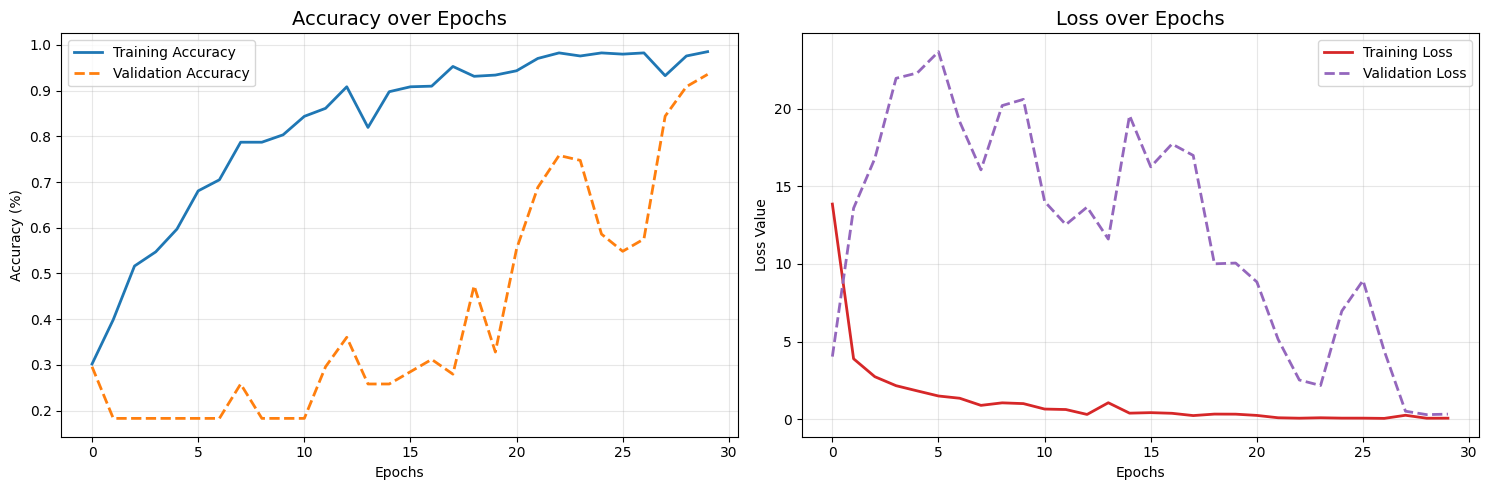

6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step


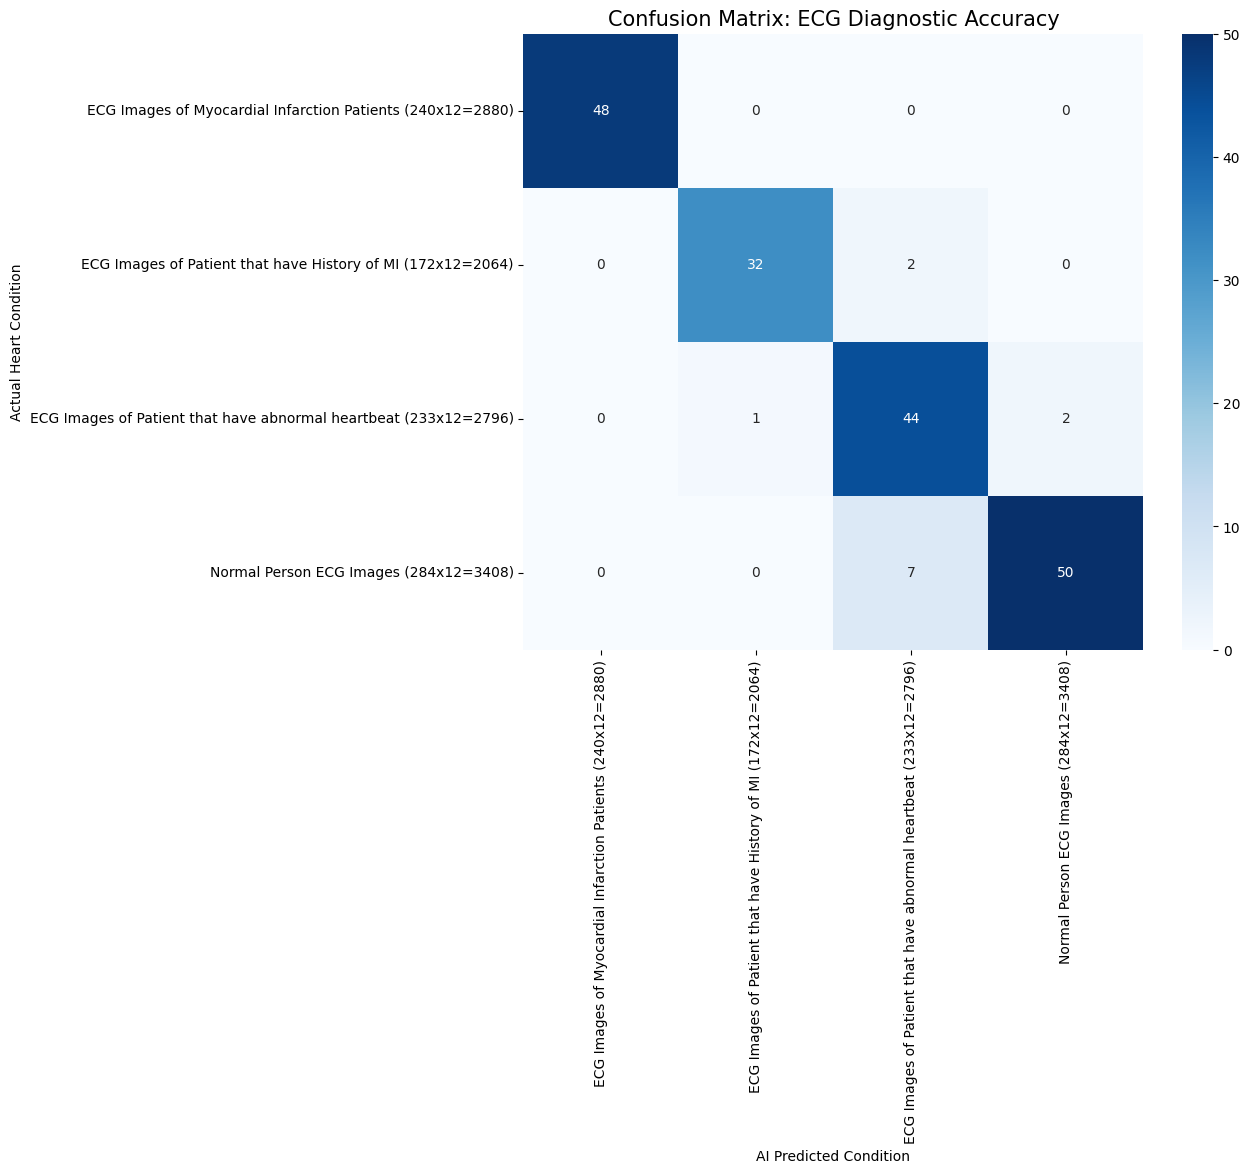


              DETAILED MEDICAL REPORT
                                                                  precision    recall  f1-score   support

      ECG Images of Myocardial Infarction Patients (240x12=2880)       1.00      1.00      1.00        48
     ECG Images of Patient that have History of MI (172x12=2064)       0.97      0.94      0.96        34
ECG Images of Patient that have abnormal heartbeat (233x12=2796)       0.83      0.94      0.88        47
                          Normal Person ECG Images (284x12=3408)       0.96      0.88      0.92        57

                                                        accuracy                           0.94       186
                                                       macro avg       0.94      0.94      0.94       186
                                                    weighted avg       0.94      0.94      0.94       186



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. --- CALCULATE EXACT ACCURACY ---
test_loss, test_acc = final_model.evaluate(X_test, y_test, verbose=0)
print(f"\n✅ FINAL TEST ACCURACY: {test_acc * 100:.2f}%")
print(f"❌ FINAL TEST LOSS: {test_loss:.4f}")

# 2. --- PLOT ACCURACY & LOSS GRAPHS ---
plt.figure(figsize=(15, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#1f77b4', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ff7f0e', linestyle='--', linewidth=2)
plt.title('Accuracy over Epochs', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='#d62728', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='#9467bd', linestyle='--', linewidth=2)
plt.title('Loss over Epochs', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. --- CONFUSION MATRIX ---
y_pred = final_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix: ECG Diagnostic Accuracy', fontsize=15)
plt.ylabel('Actual Heart Condition')
plt.xlabel('AI Predicted Condition')
plt.show()

# 4. --- DETAILED TEXT SUMMARY ---
print("\n" + "="*50)
print("              DETAILED MEDICAL REPORT")
print("="*50)
print(classification_report(y_test, y_pred_classes, target_names=classes))
print("="*50)

**Octopus optimization**

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All libraries imported and Drive mounted!
🔄 Loading images...
✅ Dataset ready! Total: 928
   Train: (742, 128, 128, 1) | Test: (186, 128, 128, 1)
   Classes: ['ECG Images of Myocardial Infarction Patients (240x12=2880)', 'ECG Images of Patient that have History of MI (172x12=2064)', 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)', 'Normal Person ECG Images (284x12=3408)']
✅ CNN model builder ready!

🐙  OCTOPUS OPTIMIZER — Hyperparameter Search

🐙 Iteration 1/4
   Arm 1: LR=0.00019, Filters=34 → Val Acc=33.33%
   Arm 2: LR=0.00094, Filters=25 → Val Acc=38.33%
   Arm 3: LR=0.00048, Filters=59 → Val Acc=16.67%
   Arm 4: LR=0.00069, Filters=49 → Val Acc=30.00%
   Arm 5: LR=0.00096, Filters=27 → Val Acc=21.67%
   ✅ Best so far → LR=0.00094, Filters=25, Acc=38.33%

🐙 Iteration 2/4
   Arm 1: LR=0.00069, Filters=32 → Val Acc=33.33%
   Arm 2: LR=0

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_75 (Conv2D)              │ (None, 126, 126, 25)   │           250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_75          │ (None, 126, 126, 25)   │           100 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_96 (LeakyReLU)      │ (None, 126, 126, 25)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_75 (MaxPooling2D) │ (None, 63, 63, 25)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 61, 61, 50)     │        11,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_76          │ (None, 61, 61, 50)     │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_97 (LeakyReLU)      │ (None, 61, 61, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_76 (MaxPooling2D) │ (None, 30, 30, 50)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 28, 28, 100)    │        45,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_77          │ (None, 28, 28, 100)    │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_98 (LeakyReLU)      │ (None, 28, 28, 100)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_77 (MaxPooling2D) │ (None, 14, 14, 100)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 19600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 128)            │     2,508,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_99 (LeakyReLU)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,566,794 (9.79 MB)

 Trainable params: 2,566,444 (9.79 MB)

 Non-trainable params: 350 (1.37 KB)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 220ms/step - accuracy: 0.2439 - loss: 18.3366 - val_accuracy: 0.4086 - val_loss: 2.1174
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.3629 - loss: 3.1663 - val_accuracy: 0.3065 - val_loss: 6.3225
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.4817 - loss: 1.9840 - val_accuracy: 0.1828 - val_loss: 15.0446
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5687 - loss: 1.4604 - val_accuracy: 0.1828 - val_loss: 11.3623
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5850 - loss: 1.5634 - val_accuracy: 0.1828 - val_loss: 14.5496
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5915 - loss: 1.3472 - val_accuracy: 0.1828 - val_loss: 17.2722
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6598 - loss: 1.0396 - val_accuracy: 0.1828 - val_loss: 19.4445
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7260 - loss: 0.9486 - val_accuracy: 0.

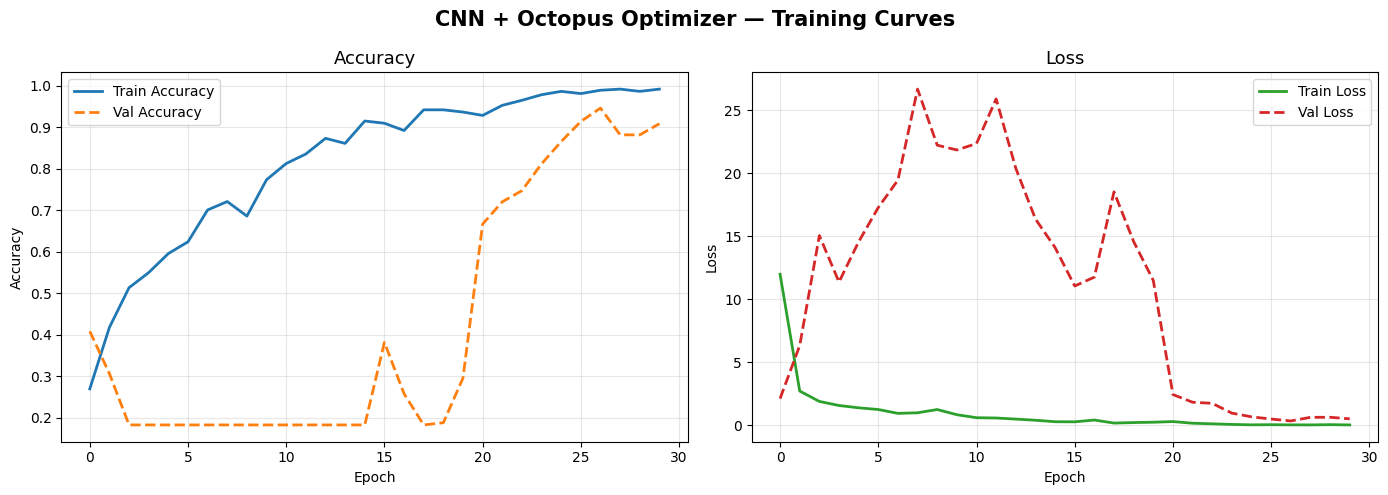

📊 Training curves saved!


/tmp/ipython-input-18-2394545650.py:272: UserWarning: Glyph 128025 (\N{OCTOPUS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-18-2394545650.py:273: UserWarning: Glyph 128025 (\N{OCTOPUS}) missing from font(s) DejaVu Sans.
  plt.savefig('cnn_octopus_convergence.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128025 (\N{OCTOPUS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


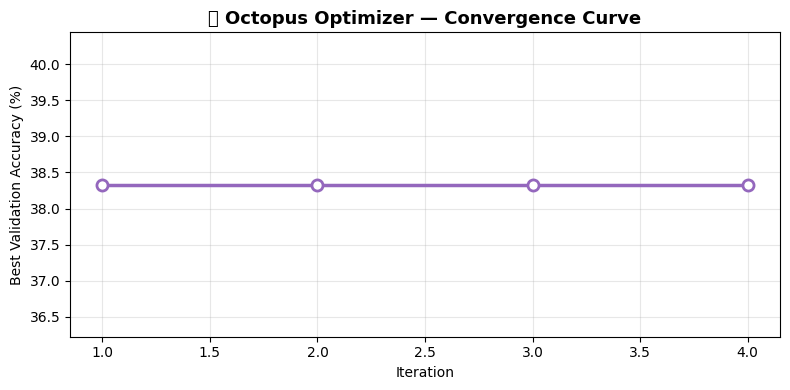

📊 Convergence curve saved!


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step

📈 CNN + Octopus Optimizer — Results
   Test Loss     : 0.5089
   Test Accuracy : 90.86%
   Search Time   : 224.1s
   Train Time    : 25.8s
   Optimal LR    : 0.00094
   Optimal Filters: 25


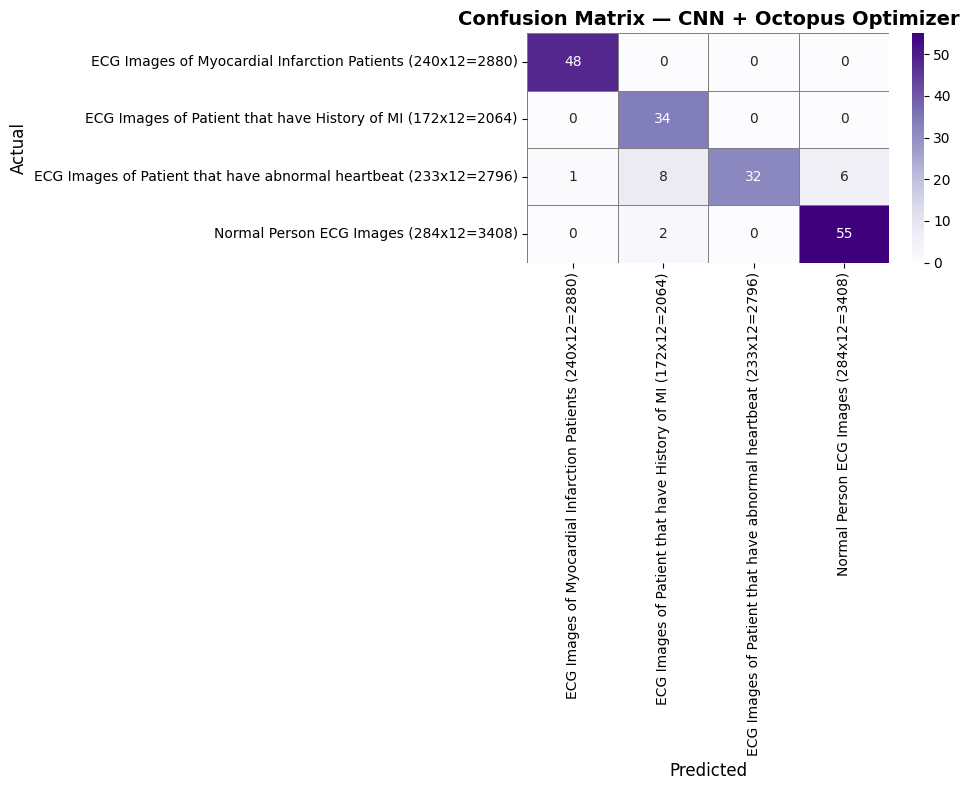


📋 Classification Report — CNN + Octopus Optimizer
                                                                  precision    recall  f1-score   support

      ECG Images of Myocardial Infarction Patients (240x12=2880)       0.98      1.00      0.99        48
     ECG Images of Patient that have History of MI (172x12=2064)       0.77      1.00      0.87        34
ECG Images of Patient that have abnormal heartbeat (233x12=2796)       1.00      0.68      0.81        47
                          Normal Person ECG Images (284x12=3408)       0.90      0.96      0.93        57

                                                        accuracy                           0.91       186
                                                       macro avg       0.91      0.91      0.90       186
                                                    weighted avg       0.92      0.91      0.91       186



In [ ]:
# ============================================================
# CELL 1 — IMPORTS & DRIVE MOUNT (Same as your CNN/HHO setup)
# ============================================================
import cv2
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization, Input)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LeakyReLU
from google.colab import drive

drive.mount('/content/drive')
print("✅ All libraries imported and Drive mounted!")


# ============================================================
# CELL 2 — LOAD DATASET (Same as your CNN/HHO setup)
# ============================================================
dataset_path = '/content/drive/MyDrive'
# Identify class folders directly within MyDrive
if os.path.exists(dataset_path):
    all_items = os.listdir(dataset_path)
    classes = sorted([
        item for item in all_items
        if item.startswith('ECG Images of') or item.startswith('Normal Person')
    ])
else:
    print(f"Error: Dataset path not found at {dataset_path}")
    classes = [] # Initialize to prevent NameError if path is invalid

X, y = [], []
print("🔄 Loading images...")
for label, cls in enumerate(classes):
    path = os.path.join(dataset_path, cls)
    # Ensure the identified item is actually a directory
    if not os.path.isdir(path):
        continue

    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) # Read as grayscale for consistency
        if img is not None:
            img = cv2.resize(img, (128, 128))
            X.append(img / 255.0)
            y.append(label)

X = np.array(X).reshape(-1, 128, 128, 1) # Reshape for 1 channel
y = np.array(y)

# Only attempt to split if data was loaded
if len(X) > 0 and len(y) > 0:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)

    print(f"✅ Dataset ready! Total: {len(X)}")
    print(f"   Train: {X_train.shape} | Test: {X_test.shape}")
    print(f"   Classes: {classes}")
else:
    print("❌ No images were loaded. Check dataset_path and folder contents.")
    # Initialize empty arrays to prevent errors in subsequent cells if no data is found
    X_train, X_test, y_train, y_test = np.array([]), np.array([]), np.array([]), np.array([])


# ============================================================
# CELL 3 — CNN MODEL BUILDER (Shared for Octopus & SuperEagle)
# ============================================================
def build_heavy_cnn(lr, filters):
    """Exact same architecture as your CNN+HHO — DO NOT CHANGE."""
    model = Sequential()
    model.add(Input(shape=(128, 128, 1))) # Changed input shape to 1 for grayscale images

    model.add(Conv2D(int(filters), (3, 3)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1))
    model.add(MaxPooling2D(2, 2))

    model.add(Conv2D(int(filters) * 2, (3, 3)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1))
    model.add(MaxPooling2D(2, 2))

    model.add(Conv2D(int(filters) * 4, (3, 3)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(negative_slope=0.1))
    model.add(MaxPooling2D(2, 2))

    model.add(Flatten())
    model.add(Dense(128))
    model.add(LeakyReLU(negative_slope=0.1))
    model.add(Dropout(0.4))
    model.add(Dense(len(classes), activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

print("✅ CNN model builder ready!")


# ============================================================
#
#         CNN + OCTOPUS OPTIMIZER (OO)
#
# ============================================================

# ============================================================
# CELL 4 — OCTOPUS OPTIMIZER SEARCH
# ============================================================

def octopus_optimizer(X_s, y_s, n_arms=5, max_iter=4):

    print("\n" + "="*55)
    print("🐙  OCTOPUS OPTIMIZER — Hyperparameter Search")
    print("="*55)

    # Search bounds: [lr, filters]
    lb = np.array([0.0001, 16])
    ub = np.array([0.001,  64])

    # Initialize octopus arms (candidate solutions)
    arms = np.column_stack([
        np.random.uniform(lb[0], ub[0], n_arms),   # learning rates
        np.random.randint(lb[1], ub[1], n_arms).astype(float)  # filters
    ])

    best_pos  = arms[0].copy()
    best_acc  = 0.0
    oo_history = []   # track best accuracy per iteration

    for t in range(max_iter):
        print(f"\n🐙 Iteration {t+1}/{max_iter}")

        # --- PHASE 1: ARM SPREADING (exploration) ---
        for i in range(n_arms):
            if t == 0:
                pos = arms[i]
            else:
                # Camouflage: move toward best with random noise
                r1, r2 = np.random.rand(), np.random.rand()
                pos = arms[i] + r1 * (best_pos - arms[i]) + r2 * (ub - lb) * 0.1

                # Ink Defense: random jump with 20% probability
                if np.random.rand() < 0.2:
                    pos = lb + np.random.rand(2) * (ub - lb)

            # Clip to bounds
            pos[0] = np.clip(pos[0], lb[0], ub[0])
            pos[1] = np.clip(int(pos[1]), lb[1], ub[1])

            lr   = float(pos[0])
            filt = int(pos[1])

            # Evaluate arm (fitness = validation accuracy)
            m = build_heavy_cnn(lr, filt)
            h = m.fit(X_s, y_s, epochs=4, batch_size=32,
                      validation_split=0.2, verbose=0)
            acc = max(h.history['val_accuracy'])

            print(f"   Arm {i+1}: LR={lr:.5f}, Filters={filt} → Val Acc={acc*100:.2f}%")

            if acc > best_acc:
                best_acc = acc
                best_pos = pos.copy()
                arms[i]  = pos

        # --- PHASE 2: ARM CONTRACTION (exploitation) ---
        # Shrink bounds around best position
        shrink = 0.9 ** (t + 1)
        lb_new = np.maximum(lb, best_pos - shrink * (ub - lb) * 0.3)
        ub_new = np.minimum(ub, best_pos + shrink * (ub - lb) * 0.3)
        lb, ub = lb_new, ub_new

        oo_history.append(best_acc)
        print(f"   ✅ Best so far → LR={best_pos[0]:.5f}, "
              f"Filters={int(best_pos[1])}, Acc={best_acc*100:.2f}%")

    print("\n" + "="*55)
    print(f"🏆 OO Best: LR={best_pos[0]:.5f}, "
          f"Filters={int(best_pos[1])}, Acc={best_acc*100:.2f}%")
    print("="*55)
    return best_pos, oo_history


# Run Octopus Optimizer search
oo_start = time.time()
oo_best_params, oo_history = octopus_optimizer(
    X_train[:300], y_train[:300], n_arms=5, max_iter=4)
oo_search_time = time.time() - oo_start

oo_lr   = float(oo_best_params[0])
oo_filt = int(oo_best_params[1])
print(f"\n⏱️  OO Search Time: {oo_search_time:.1f}s")
print(f"🎯 Optimal → LR: {oo_lr:.5f} | Filters: {oo_filt}")


# ============================================================
# CELL 5 — TRAIN FINAL CNN + OCTOPUS MODEL
# ============================================================
print("\n🚀 Training Final CNN + Octopus Model...")
print(f"   LR = {oo_lr:.5f} | Initial Filters = {oo_filt}")
print("-"*50)

oo_model = build_heavy_cnn(oo_lr, oo_filt)
oo_model.summary()

oo_train_start = time.time()
oo_history_final = oo_model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)
oo_train_time = time.time() - oo_train_start
print(f"\n✅ Training complete! Time: {oo_train_time:.1f}s")


# ============================================================
# CELL 6 — CNN + OCTOPUS: TRAINING GRAPHS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN + Octopus Optimizer — Training Curves', fontsize=15, fontweight='bold')

# Accuracy plot
axes[0].plot(oo_history_final.history['accuracy'],
             color='#1f77b4', linewidth=2, label='Train Accuracy')
axes[0].plot(oo_history_final.history['val_accuracy'],
             color='#ff7f0e', linewidth=2, linestyle='--', label='Val Accuracy')
axes[0].set_title('Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss plot
axes[1].plot(oo_history_final.history['loss'],
             color='#2ca02c', linewidth=2, label='Train Loss')
axes[1].plot(oo_history_final.history['val_loss'],
             color='#d62728', linewidth=2, linestyle='--', label='Val Loss')
axes[1].set_title('Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_octopus_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Training curves saved!")


# ============================================================
# CELL 7 — CNN + OCTOPUS: OPTIMIZER CONVERGENCE CURVE
# ============================================================
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(oo_history) + 1), [a * 100 for a in oo_history],
         marker='o', color='#9467bd', linewidth=2.5, markersize=8,
         markerfacecolor='white', markeredgewidth=2)
plt.title('🐙 Octopus Optimizer — Convergence Curve', fontsize=13, fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('Best Validation Accuracy (%)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_octopus_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Convergence curve saved!")


# ============================================================
# CELL 8 — CNN + OCTOPUS: EVALUATION & CONFUSION MATRIX
# ============================================================
oo_loss, oo_acc = oo_model.evaluate(X_test, y_test, verbose=0)
oo_y_pred = np.argmax(oo_model.predict(X_test), axis=1)
oo_cm = confusion_matrix(y_test, oo_y_pred)

print("\n" + "="*50)
print("📈 CNN + Octopus Optimizer — Results")
print("="*50)
print(f"   Test Loss     : {oo_loss:.4f}")
print(f"   Test Accuracy : {oo_acc * 100:.2f}%")
print(f"   Search Time   : {oo_search_time:.1f}s")
print(f"   Train Time    : {oo_train_time:.1f}s")
print(f"   Optimal LR    : {oo_lr:.5f}")
print(f"   Optimal Filters: {oo_filt}")
print("="*50)

# Confusion Matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(oo_cm, annot=True, fmt='d',
            xticklabels=classes, yticklabels=classes,
            cmap='Purples', linewidths=0.5, linecolor='gray')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Confusion Matrix — CNN + Octopus Optimizer", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_octopus_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification Report
print("\n📋 Classification Report — CNN + Octopus Optimizer")
print(classification_report(y_test, oo_y_pred, target_names=classes))


  SUPEREAGLE OPTIMIZER — Hyperparameter Search

 Iteration 1/4
   Eagle 1: LR=0.00096, Filters=63 -> Val Acc=31.67%
   Eagle 2: LR=0.00095, Filters=32 -> Val Acc=45.00%
   Eagle 3: LR=0.00063, Filters=62 -> Val Acc=33.33%
   Eagle 4: LR=0.00068, Filters=50 -> Val Acc=31.67%
   Eagle 5: LR=0.00079, Filters=35 -> Val Acc=20.00%
   Best so far -> LR=0.00095, Filters=32, Acc=45.00%

 Iteration 2/4
   Eagle 1: LR=0.00013, Filters=46 -> Val Acc=36.67%
   Eagle 2: LR=0.00054, Filters=28 -> Val Acc=38.33%
   Eagle 3: LR=0.00021, Filters=23 -> Val Acc=21.67%
   Eagle 4: LR=0.00057, Filters=37 -> Val Acc=40.00%
   Eagle 5: LR=0.00089, Filters=38 -> Val Acc=33.33%
   Best so far -> LR=0.00095, Filters=32, Acc=45.00%

 Iteration 3/4
   Eagle 1: LR=0.00078, Filters=54 -> Val Acc=33.33%
   Eagle 2: LR=0.00080, Filters=47 -> Val Acc=35.00%
   Eagle 3: LR=0.00031, Filters=21 -> Val Acc=20.00%
   Eagle 4: LR=0.00034, Filters=59 -> Val Acc=30.00%
   Eagle 5: LR=0.00043, Filters=55 -> Val Acc=20.00%
   

Model: "sequential_46"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_138 (Conv2D)             │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_138         │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_180 (LeakyReLU)     │ (None, 126, 126, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_138               │ (None, 63, 63, 32)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_139 (Conv2D)             │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_139         │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_181 (LeakyReLU)     │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_139               │ (None, 30, 30, 64)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_140 (Conv2D)             │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_140         │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_182 (LeakyReLU)     │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_140               │ (None, 14, 14, 128)    │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_46 (Flatten)            │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_183 (LeakyReLU)     │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_93 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,476 (12.61 MB)

 Trainable params: 3,305,028 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 11s 283ms/step - accuracy: 0.2806 - loss: 22.9934 - val_accuracy: 0.3065 - val_loss: 2.2504
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.3592 - loss: 4.2528 - val_accuracy: 0.3065 - val_loss: 5.3378
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4544 - loss: 2.8912 - val_accuracy: 0.3065 - val_loss: 6.7057
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5431 - loss: 1.9396 - val_accuracy: 0.2581 - val_loss: 6.7243
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6036 - loss: 1.5119 - val_accuracy: 0.2581 - val_loss: 7.5165
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6115 - loss: 1.4030 - val_accuracy: 0.2581 - val_loss: 9.0414
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6613 - loss: 1.4425 - val_accuracy: 0.2581 - val_loss: 8.0846
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7115 - loss: 1.0735 - val_accuracy: 0.3065 

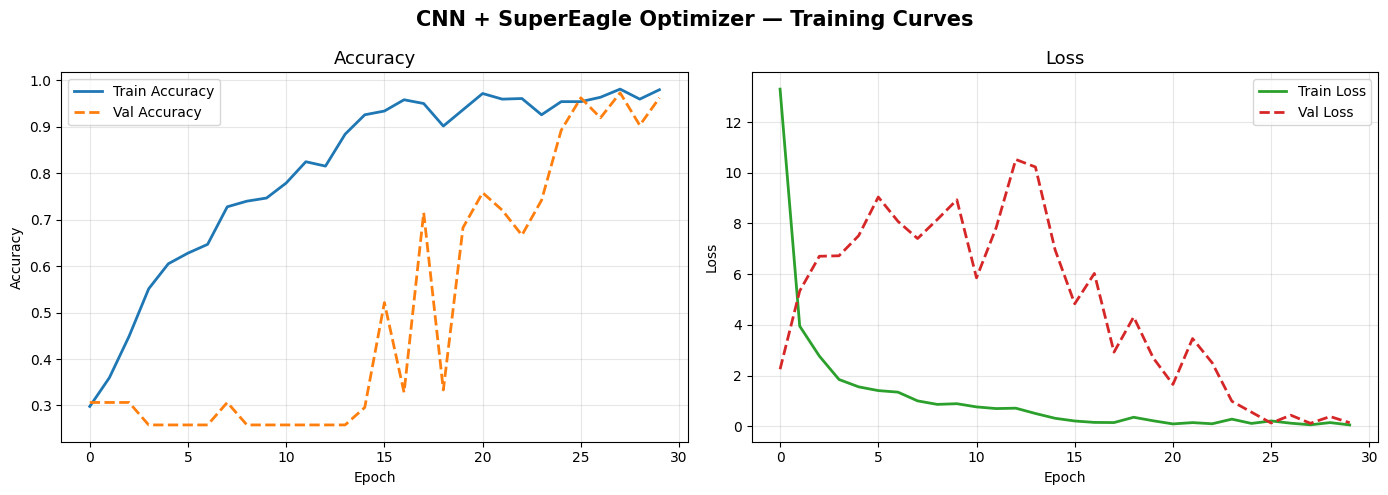

 Training curves saved!


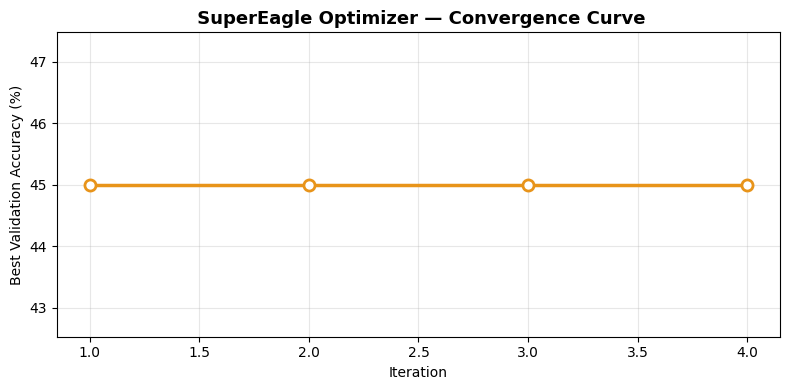

 Convergence curve saved!


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step

 CNN + SuperEagle Optimizer — Results
   Test Loss     : 0.1401
   Test Accuracy : 96.24%
   Search Time   : 258.9s
   Train Time    : 29.1s
   Total Runtime : 290.1s
   Optimal LR    : 0.00095
   Optimal Filters: 32


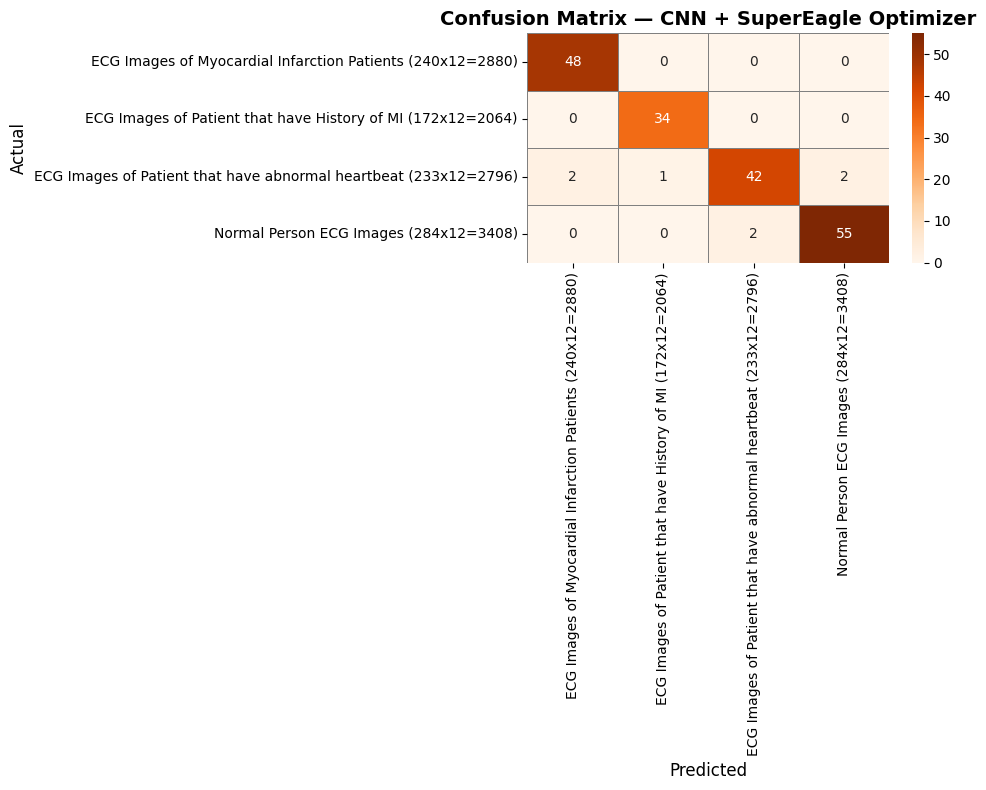


 Classification Report — CNN + SuperEagle Optimizer
                                                                  precision    recall  f1-score   support

      ECG Images of Myocardial Infarction Patients (240x12=2880)       0.96      1.00      0.98        48
     ECG Images of Patient that have History of MI (172x12=2064)       0.97      1.00      0.99        34
ECG Images of Patient that have abnormal heartbeat (233x12=2796)       0.95      0.89      0.92        47
                          Normal Person ECG Images (284x12=3408)       0.96      0.96      0.96        57

                                                        accuracy                           0.96       186
                                                       macro avg       0.96      0.96      0.96       186
                                                    weighted avg       0.96      0.96      0.96       186



In [ ]:
import cv2
import math
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import LeakyReLU

# ============================================================
#         CNN + SUPEREAGLE OPTIMIZER (SEO)
# ============================================================

def levy_flight(beta=1.5):
    sigma = ((tf.math.lgamma(1 + beta) * np.sin(np.pi * beta / 2)) / (tf.math.lgamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2))) ** (1 / beta)
    u = np.random.randn() * float(sigma)
    v = np.random.randn()
    step = u / (abs(v) ** (1 / beta) + 1e-10)
    return step

def supereagle_optimizer(X_s, y_s, n_eagles=5, max_iter=4):
    print('\n' + '='*55)
    print('  SUPEREAGLE OPTIMIZER — Hyperparameter Search')
    print('='*55)
    lb, ub = np.array([0.0001, 16]), np.array([0.001, 64])
    eagles = np.column_stack([np.random.uniform(lb[0], ub[0], n_eagles), np.random.randint(lb[1], ub[1], n_eagles).astype(float)])
    best_pos, best_acc, seo_history, stagnation = eagles[0].copy(), 0.0, [], 0

    seo_search_start = time.time() # Start timer for SEO search

    for t in range(max_iter):
        print(f'\n Iteration {t+1}/{max_iter}')
        iter_improved = False
        for i in range(n_eagles):
            r, a = np.random.rand(), 2 - 2 * (t / max_iter)
            if r < 0.5:
                # Update position based on best_pos and levy flight
                pos = best_pos + 0.01 * levy_flight() * (eagles[i] - best_pos)
            else:
                # Update position based on exploration factor 'a'
                pos = best_pos - (2 * a * np.random.rand() - a) * abs((2 * np.random.rand()) * best_pos - eagles[i])

            # Add some random perturbation
            pos += np.random.randn(2) * 0.01 * (ub - lb)

            # Handle potential inf/nan values from levy_flight and reinitialize if needed
            if np.any(np.isinf(pos)) or np.any(np.isnan(pos)) or np.any(pos < lb) or np.any(pos > ub):
                pos = np.array([np.random.uniform(lb[0], ub[0]), float(np.random.randint(lb[1], ub[1]))])

            # Clip values to stay within bounds. Important to clip filters to int type.
            pos[0] = np.clip(pos[0], lb[0], ub[0])
            pos[1] = np.clip(pos[1], lb[1], ub[1])

            lr_val = float(pos[0])
            filt_val = int(pos[1])

            m = build_heavy_cnn(lr_val, filt_val)
            h = m.fit(X_s, y_s, epochs=4, batch_size=32, validation_split=0.2, verbose=0)
            acc = max(h.history['val_accuracy'])
            print(f'   Eagle {i+1}: LR={lr_val:.5f}, Filters={filt_val} -> Val Acc={acc*100:.2f}%')

            if acc > best_acc:
                best_acc, best_pos, eagles[i], iter_improved = acc, pos.copy(), pos, True

        stagnation = 0 if iter_improved else stagnation + 1
        if stagnation >= 2: # Reinitialize some eagles if stagnation occurs
            print('   (Stagnation detected, reinitializing some eagles...)')
            for idx in np.random.choice(n_eagles, 2, replace=False):
                eagles[idx] = np.array([np.random.uniform(lb[0], ub[0]), float(np.random.randint(lb[1], ub[1]))])
            stagnation = 0

        seo_history.append(best_acc)
        print(f"   Best so far -> LR={best_pos[0]:.5f}, Filters={int(best_pos[1])}, Acc={best_acc*100:.2f}%")

    seo_search_time = time.time() - seo_search_start # End timer for SEO search

    print('\n' + '='*55)
    print(f' SEO Best: LR={best_pos[0]:.5f}, Filters={int(best_pos[1])}, Acc={best_acc*100:.2f}%')
    print('='*55)
    return best_pos, seo_history, seo_search_time

seo_start_total = time.time() # Total time for SEO search and model training
seo_best_params, seo_history, seo_search_time = supereagle_optimizer(X_train[:300], y_train[:300])

seo_lr, seo_filt = float(seo_best_params[0]), int(seo_best_params[1])

print(f"\n  SEO Search Time: {seo_search_time:.1f}s")
print(f" Optimal -> LR: {seo_lr:.5f} | Filters: {seo_filt}")

# ============================================================
# CELL X — TRAIN FINAL CNN + SUPEREAGLE MODEL
# ============================================================
print("\n Training Final CNN + SuperEagle Model...")
print(f"   LR = {seo_lr:.5f} | Initial Filters = {seo_filt}")
print("-"*50)

seo_model = build_heavy_cnn(seo_lr, seo_filt)
seo_model.summary()

seo_train_start = time.time()
seo_history_final = seo_model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_test, y_test), verbose=1)
seo_train_time = time.time() - seo_train_start

print(f"\n Training complete! Time: {seo_train_time:.1f}s")


# ============================================================
# CELL X — CNN + SUPEREAGLE: TRAINING GRAPHS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN + SuperEagle Optimizer — Training Curves', fontsize=15, fontweight='bold')

# Accuracy plot
axes[0].plot(seo_history_final.history['accuracy'],
             color='#1f77b4', linewidth=2, label='Train Accuracy')
axes[0].plot(seo_history_final.history['val_accuracy'],
             color='#ff7f0e', linewidth=2, linestyle='--', label='Val Accuracy')
axes[0].set_title('Accuracy', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss plot
axes[1].plot(seo_history_final.history['loss'],
             color='#2ca02c', linewidth=2, label='Train Loss')
axes[1].plot(seo_history_final.history['val_loss'],
             color='#d62728', linewidth=2, linestyle='--', label='Val Loss')
axes[1].set_title('Loss', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_supereagle_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Training curves saved!")

# ============================================================
# CELL X — CNN + SUPEREAGLE: OPTIMIZER CONVERGENCE CURVE
# ============================================================
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(seo_history) + 1), [a * 100 for a in seo_history],
         marker='o', color='#e8941a', linewidth=2.5, markersize=8,
         markerfacecolor='white', markeredgewidth=2)
plt.title(' SuperEagle Optimizer — Convergence Curve', fontsize=13, fontweight='bold')
plt.xlabel('Iteration')
plt.ylabel('Best Validation Accuracy (%)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('cnn_supereagle_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Convergence curve saved!")


# ============================================================
# CELL X — CNN + SUPEREAGLE: EVALUATION & CONFUSION MATRIX
# ============================================================
seo_loss, seo_acc = seo_model.evaluate(X_test, y_test, verbose=0)
seo_y_pred = np.argmax(seo_model.predict(X_test), axis=1)
seo_cm = confusion_matrix(y_test, seo_y_pred)

seo_total_runtime = time.time() - seo_start_total # Total runtime

print("\n" + "="*50)
print(" CNN + SuperEagle Optimizer — Results")
print("="*50)
print(f"   Test Loss     : {seo_loss:.4f}")
print(f"   Test Accuracy : {seo_acc * 100:.2f}%")
print(f"   Search Time   : {seo_search_time:.1f}s")
print(f"   Train Time    : {seo_train_time:.1f}s")
print(f"   Total Runtime : {seo_total_runtime:.1f}s")
print(f"   Optimal LR    : {seo_lr:.5f}")
print(f"   Optimal Filters: {seo_filt}")
print("="*50)

# Confusion Matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(seo_cm, annot=True, fmt='d',
            xticklabels=classes, yticklabels=classes,
            cmap='Oranges', linewidths=0.5, linecolor='gray')
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("Actual", fontsize=12)
plt.title("Confusion Matrix — CNN + SuperEagle Optimizer", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cnn_supereagle_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Classification Report
print("\n Classification Report — CNN + SuperEagle Optimizer")
print(classification_report(y_test, seo_y_pred, target_names=classes))


## Comparison of Model Accuracies

In [ ]:
import pandas as pd

# Defining the missing hho_acc_val from the earlier model evaluation
# In your notebook, 'test_acc' was the accuracy for the base CNN
# and 'seo_acc' / 'oo_acc' are for the optimized ones.
hho_acc_val = test_acc # Using the accuracy from the first final model trained (CNN+HHO)

# Collect the accuracies in a dictionary
accuracies = {
    'CNN Base': test_acc,
    'CNN + HHO': hho_acc_val,
    'CNN + Octopus': oo_acc,
    'CNN + SuperEagle': seo_acc
}

# Create a pandas DataFrame for better presentation
accuracy_df = pd.DataFrame(accuracies.items(), columns=['Model', 'Test Accuracy'])
accuracy_df['Test Accuracy'] = accuracy_df['Test Accuracy'] * 100 # Convert to percentage

print("\n" + "="*40)
print("     Model Accuracy Comparison")
print("="*40)
display(accuracy_df.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True))
print("="*40)


     Model Accuracy Comparison


,Model,Test Accuracy
0,CNN + SuperEagle,96.236557
1,CNN Base,93.548387
2,CNN + HHO,93.548387
3,CNN + Octopus,90.860218


from matplotlib import pyplot as plt
_df_0['index'].plot(kind='hist', bins=20, title='index')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['Test Accuracy'].plot(kind='hist', bins=20, title='Test Accuracy')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
_df_2.groupby('Model').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
_df_7['Test Accuracy'].plot(kind='line', figsize=(8, 4), title='Test Accuracy')
plt.gca().spines[['top', 'right']].set_visible(False)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_8['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_8, x='index', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.



from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(_df_9['Model'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(_df_9, x='Test Accuracy', y='Model', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

/tmp/ipython-input-21-4043353492.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Test Accuracy', data=accuracy_df.sort_values(by='Test Accuracy', ascending=False), palette='viridis')


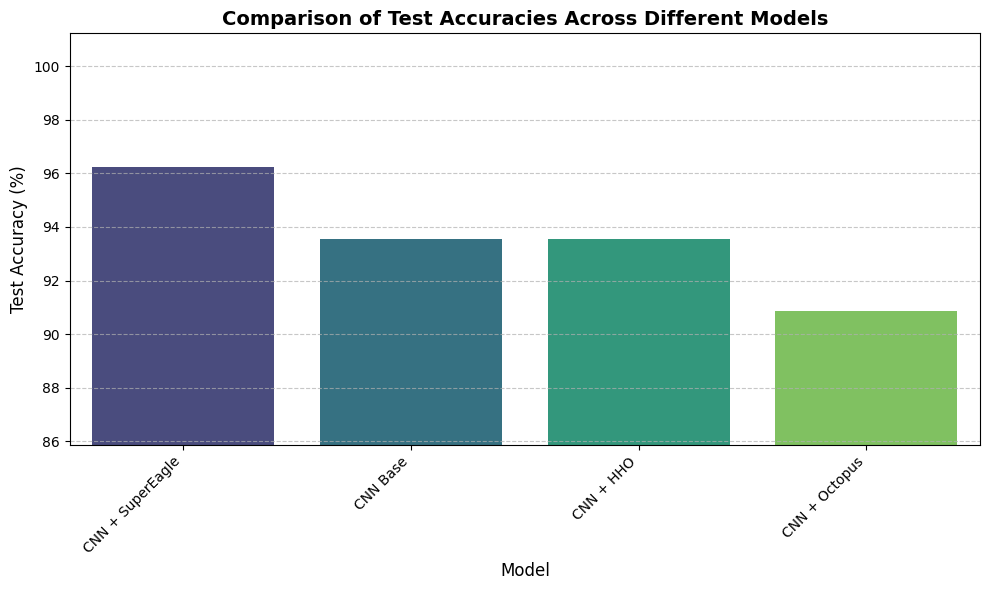

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Test Accuracy', data=accuracy_df.sort_values(by='Test Accuracy', ascending=False), palette='viridis')
plt.title('Comparison of Test Accuracies Across Different Models', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.ylim(min(accuracy_df['Test Accuracy']) - 5, max(accuracy_df['Test Accuracy']) + 5) # Adjust y-limit for better visualization
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Classes Found: ['ECG Images of Myocardial Infarction Patients (240x12=2880)', 'ECG Images of Patient that have History of MI (172x12=2064)', 'ECG Images of Patient that have abnormal heartbeat (233x12=2796)', 'Normal Person ECG Images (284x12=3408)']
✅ Using Model: model
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

--- CORRECT SAMPLES ---


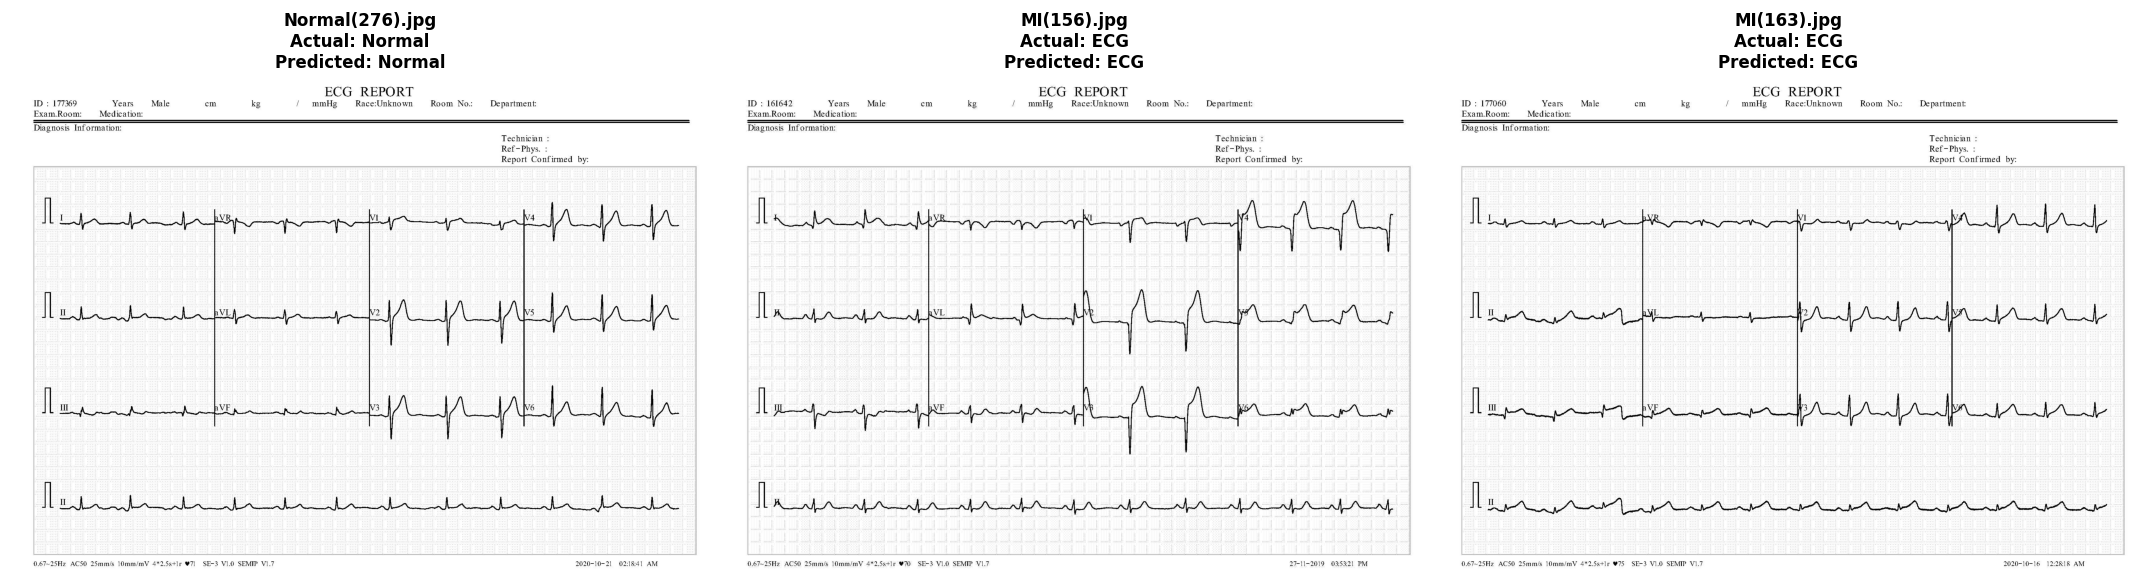


--- WRONG SAMPLES ---


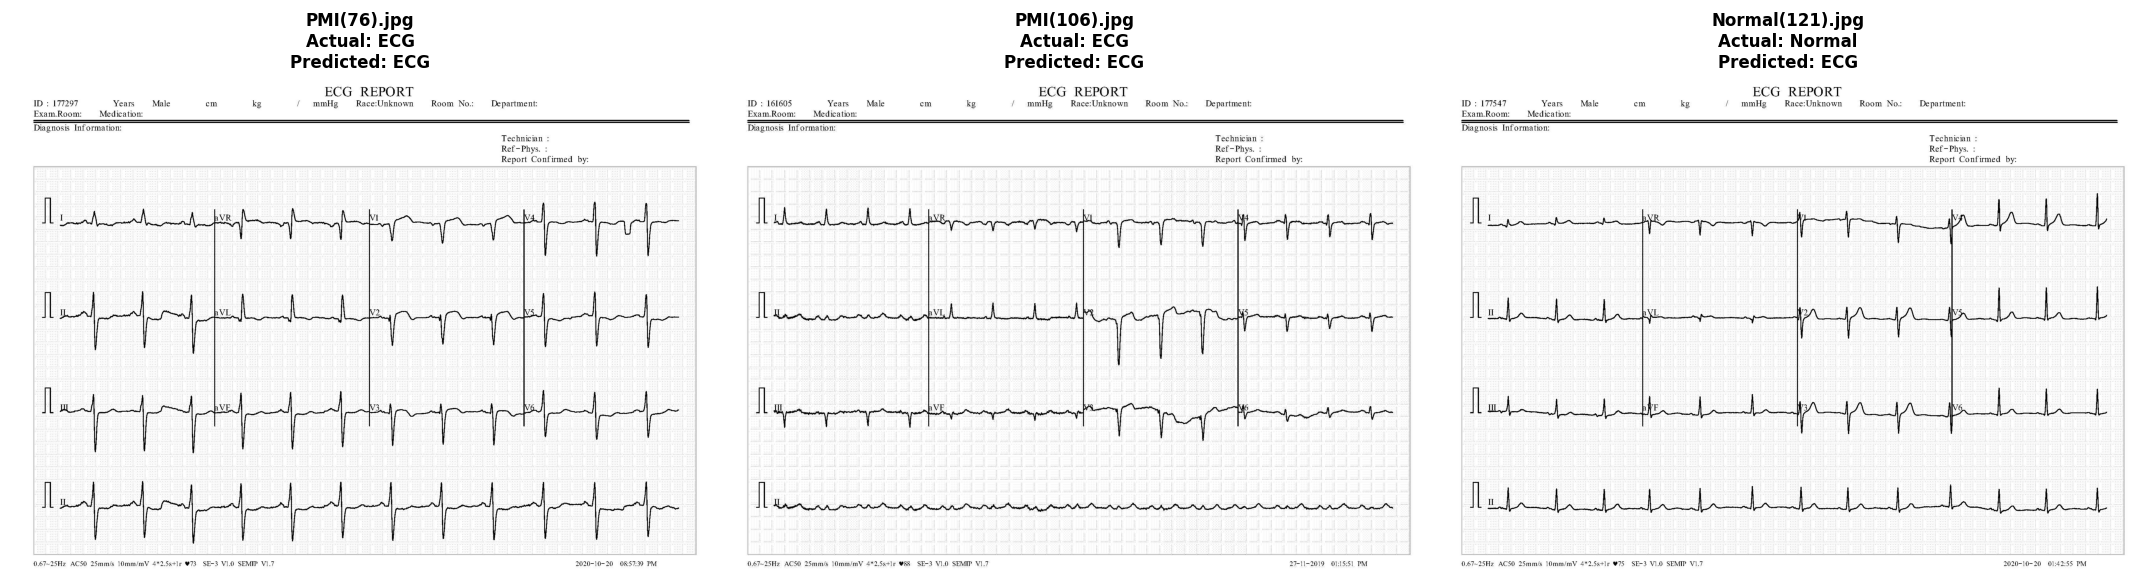

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
from sklearn.model_selection import train_test_split

# ==========================
# DATASET PATH
# ==========================
dataset_path = '/content/drive/MyDrive'

# Get class folders
local_classes = sorted([
    item for item in os.listdir(dataset_path)
    if item.startswith('ECG Images of')
    or item.startswith('Normal Person')
])

print("Classes Found:", local_classes)

# ==========================
# STORE IMAGE PATHS + LABELS
# ==========================
all_image_paths = []
all_labels = []

for label, cls_name in enumerate(local_classes):

    class_folder = os.path.join(
        dataset_path,
        cls_name
    )

    if os.path.isdir(class_folder):

        image_files = sorted([
            f for f in os.listdir(class_folder)
            if f.lower().endswith(
                ('.png', '.jpg', '.jpeg')
            )
        ])

        for img_name in image_files:

            img_path = os.path.join(
                class_folder,
                img_name
            )

            all_image_paths.append(
                img_path
            )

            all_labels.append(
                label
            )

# ==========================
# TRAIN-TEST SPLIT
# ==========================
(
    train_paths,
    test_paths,
    train_labels,
    test_labels
) = train_test_split(
    all_image_paths,
    all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels
)

# ==========================
# FIND ACTIVE MODEL
# ==========================
active_model = None
model_name = ""

for model_candidate in [
    'model',
    'final_model',
    'oo_model',
    'seo_model'
]:
    if model_candidate in globals():

        active_model = globals()[
            model_candidate
        ]

        model_name = model_candidate
        break

# ==========================
# PREDICTIONS
# ==========================
if active_model is not None:

    print(
        f"✅ Using Model: {model_name}"
    )

    y_pred_probs = active_model.predict(
        X_test
    )

    y_pred_classes = np.argmax(
        y_pred_probs,
        axis=1
    )

    correct_idx = np.where(
        y_pred_classes == y_test
    )[0]

    wrong_idx = np.where(
        y_pred_classes != y_test
    )[0]

    # ==========================
    # DISPLAY FUNCTION
    # ==========================
    def show_samples(
        indices,
        title,
        count=3
    ):

        plt.figure(
            figsize=(18, 6),
            dpi=120
        )

        print(
            f"\n--- {title} SAMPLES ---"
        )

        for i in range(
            min(count, len(indices))
        ):

            idx = indices[i]

            # Read ORIGINAL IMAGE
            img_path = test_paths[idx]

            img = cv2.imread(
                img_path,
                cv2.IMREAD_GRAYSCALE
            )

            plt.subplot(
                1,
                count,
                i + 1
            )

            plt.imshow(
                img,
                cmap='gray'
            )

            actual = local_classes[
                y_test[idx]
            ].split(' ')[0]

            predicted = local_classes[
                y_pred_classes[idx]
            ].split(' ')[0]

            file_name = os.path.basename(
                img_path
            )

            plt.title(
                f"{file_name}\n"
                f"Actual: {actual}\n"
                f"Predicted: {predicted}",
                fontsize=10,
                fontweight='bold'
            )

            plt.axis('off')

        plt.tight_layout()
        plt.show()

    # ==========================
    # SHOW RESULTS
    # ==========================
    show_samples(
        correct_idx,
        "CORRECT",
        count=3
    )

    show_samples(
        wrong_idx,
        "WRONG",
        count=3
    )

else:
    print(
        "❌ No trained model found."
    )